In [1]:
%load_ext autoreload

In [2]:
%autoreload 

import sys
sys.path.append('../../')

import numpy as np
import matplotlib.pyplot as plt

from scipy.io import loadmat

import twenty_one
import fluctuations


In [3]:
%matplotlib inline

In [4]:
data_A = np.load('../../data/PBH_dynamical_friction/PBH/power_spec_results/Delt_T21_sq_A.npz') 
data_B = np.load('../../data/PBH_dynamical_friction/PBH/power_spec_results/Delt_T21_sq_B.npz')
data_C = np.load('../../data/PBH_dynamical_friction/PBH/power_spec_results/Delt_T21_sq_C.npz')
data_D = np.load('../../data/PBH_dynamical_friction/PBH/power_spec_results/Delt_T21_sq_D.npz')

In [8]:
k_ary = data_A['k_ary']

idx_k_fid = np.abs(k_ary - 0.13).argmin()

In [26]:
mPBH_ary = [] 
f_lim_ary = [] 
for data in [data_A, data_B, data_C, data_D]:
    delt2_at_k_fid = data['xi_fft_ary'][idx_k_fid, :, :]*1e6  # shape (len(mPBH_ary), len(fPBH_ary))
    for i,mPBH in enumerate(data['mPBH_ary']): 
        mPBH_ary.append(mPBH)
        print(mPBH, delt2_at_k_fid[i])
        f_lim = 10**np.interp(np.log10(92.7), np.log10(delt2_at_k_fid[i]), np.log10(data['fPBH_ary']), left=np.nan, right=0.)
        f_lim_ary.append(f_lim)
        print(mPBH, f_lim)

10.0 [0.02335667 1.93954321]
10.0 1.0
50.0 [ 0.49797082 24.35452217]
50.0 1.0
100.0 [2.01324515e-02 4.06743811e-01 6.71383560e+00 5.64261708e+01]
100.0 1.0
500.0 [  0.45545378   7.91505867  81.32202668 285.50754299]
500.0 0.25284172731917326
1000.0 [  1.85824422  32.58263844  88.72433462 501.75253454]
1000.0 0.10599859389421355
5000.0 [  25.65927218  257.71320674  500.34243658 1380.56567869]
5000.0 0.024500433169016986
10000.0 [6.08378075e-03 5.86262297e-01 4.23711100e+01 1.56841912e+03]
10000.0 0.027137986019738245
50000.0 [7.58961296e-03 7.32222345e-01 4.99874849e+01 2.56189395e+03]
50000.0 0.02059495550959371


(1e-05, 1)

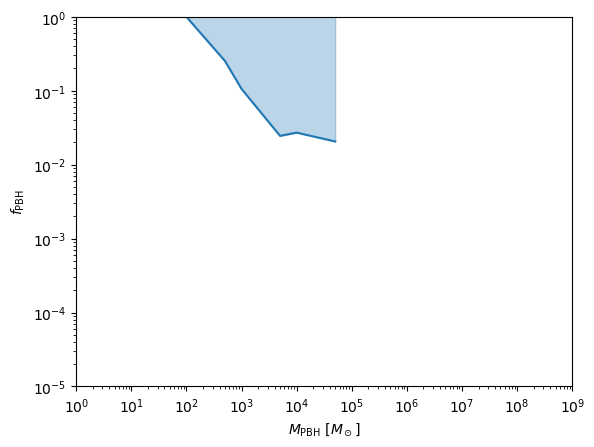

In [41]:
plt.figure() 

plt.loglog(np.array(mPBH_ary), np.array(f_lim_ary), alpha=1.) 
plt.fill_between(np.array(mPBH_ary), np.array(f_lim_ary), 1, color='C0', alpha=0.3)

plt.xlabel(r'$M_{\mathrm{PBH}}$ [$M_\odot$]')
plt.ylabel(r'$f_{\mathrm{PBH}}$')
plt.xlim(1, 1e9)
plt.ylim(1e-5, 1)

In [35]:
f_lim_ary

[1.0,
 1.0,
 1.0,
 0.25284172731917326,
 0.10599859389421355,
 0.024500433169016986,
 0.027137986019738245,
 0.02059495550959371]